Correspondence: Sudhanshu Pandey (sudhanshu.pandey@jpl.nasa.gov)

Jet Propulsion Laboratory, California Institute of Technology, Pasadena, CA 91109, USA

## Executive Summary

This notebook presents a comprehensive evaluation of gridded methane emission inventories using atmospheric flux inversions based on GOSAT (Greenhouse gases Observing SATellite) concentration measurements. It demonstrates how to account for the truth sensitivity (averaging kernel) of atmospheric flux inversions and provides an in-depth comparison between bottom-up inventories and satellite-derived emissions. The GOSAT flux inversion data utilized are sourced from Qu et al. (2024).





## Intended User

The intended user should ideally be knowledgeable about inverse problems or possess the technical skills to learn the basics of inverse problems.

### Key concepts

| Term                        | What it is                                                                                                                                                                                                                                           | Why it matters                                                                                             |
| --------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------- |
| **Bayesian flux inversion** | A statistical procedure that blends **prior** emission estimates with **observations** (e.g., GOSAT methane columns) to obtain the most probable emission field—called the **posterior**.                                                            | Provides a best-estimate emissions map *and* formal uncertainty.                                           |
| **Averaging kernel (AK)**   | A square matrix **A** that shows, grid-cell by grid-cell, how much the posterior relies on the observations versus the prior. Diagonal values close to 1 ⇒ the satellite “sees” that location well; values near 0 ⇒ little observational constraint. | Lets you adjust inventories before comparing them with the posterior, ensuring an “apples-to-apples” test. |

---

### Why do we *filter* the inventory with the AK?

A raw bottom-up inventory may place emissions in a grid cell that the satellite hardly constrains (tiny AK value).
If you compared that raw number with the well-constrained posterior next door, you would mis-diagnose an “error” that is really an artefact of observational coverage.
**Solution:** run the inventory through the same AK the inversion used.
This produces an *AK-adjusted inventory* that reflects only what the satellite could have detected.

---

### 1 · Posterior solution of the inversion

$$
\boxed{\hat{x}=x_a + A\,(x_{\text{true}}-x_a)}
$$

* $x_a$ – prior emissions fed into the inversion
* $x_{\text{true}}$ – (unknown) real emissions
* $A$ – averaging-kernel matrix
* $\hat{x}$ – posterior (the inversion’s best estimate)

---

### 2 · Applying the inversion operator to an inventory

Treat the inventory $x_{\text{inv}}$ as your proxy for “truth” and pass it through the same operator:

$$
\boxed{x_{\text{inv-est}} = x_a +  A\,(x_{\text{inv}}-x_a)}
$$

Now **$x_{\text{inv-est}}$** and **$\hat{x}$** share the same observational lens and can be compared directly:

$$
\Delta x_{\text{inv-est}} = x_{\text{inv-est}} - \hat{x}
                          = A\bigl(x_{\text{inv}} - x_{\text{true}}\bigr)
$$

This residual $\Delta x_{\text{inv-est}}$ is *independent* of the choice of prior $x_a$.

---

### 3 · Uncertainty of $\Delta x_{\text{inv-est}}$

$$
S_{\text{inv-est}}
   =A\,S_{\text{inv}}\,A^{\mathsf T}
   +S_{\text{obs}}
   +S_{\text{model}}
$$

* **$S_{\text{inv}}$** — your declared error bars for each inventory grid cell. Multiplication by $A$ shrinks them where the satellite is “blind” (low AK) and leaves them largely intact where the satellite is “sharp-eyed” (high AK).
* **$S_{\text{obs}}$** — random uncertainty in the retrievals (instrument noise, retrieval-algorithm errors).
* **$S_{\text{model}}$** — transport-model errors in mapping emissions to concentrations. In practice, many studies set $S_{\text{model}} = S_{\text{obs}}$ when explicit estimates are lacking, acknowledging that transport errors often rival measurement noise.
---


The square root of each diagonal element of $S_{\text{inv-est}}$ gives a 1-$\sigma$ bound.
The residual $\Delta x_{\text{inv-est}}$ is **statistically significant** where $|\Delta x_{\text{inv-est}}| > \sigma$ (for a 1-$\sigma$ test) or exceeds the corresponding 2-$\sigma$ threshold.
These regions mark where the inventory–posterior mismatch is unlikely to be due to chance.

---



### References

- Worden, J. R., Pandey, S., Zhang, Y., Cusworth, D. H., Qu, Z., Bloom, A. A., Ma, S., Maasakkers, J. D., Byrne, B., Duren, R., Crisp, D., Gordon, D., and Jacob, D. J.: Verifying Methane Inventories and Trends With Atmospheric Methane Data, AGU Adv., 4, https://doi.org/10.1029/2023AV000871, 2023.
- Worden, J. R., Cusworth, D. H., Qu, Z., Yin, Y., Zhang, Y., Bloom, A. A., Ma, S., Byrne, B. K., Scarpelli, T., Maasakkers, J. D., Crisp, D., Duren, R., and Jacob, D. J.: The 2019 methane budget and uncertainties at 1° resolution and each country through Bayesian integration Of GOSAT total column methane data and a priori inventory estimates, Atmos. Chem. Phys., 22, 6811–6841, https://doi.org/10.5194/acp-22-6811-2022, 2022.
- Qu, Z., Jacob, D. J., Bloom, A. A., Worden, J. R., Parker, R. J., and Boesch, H.: Inverse modeling of 2010–2022 satellite observations shows that inundation of the wet tropics drove the 2020–2022 methane surge, Proc. Natl. Acad. Sci., 121, e2402730121, https://doi.org/10.1073/pnas.2402730121, 2024.


# Initialize 

In [1]:
# Import necessary libraries for data manipulation and visualization
%load_ext autoreload 
%autoreload 2  
from pylab import *  # Import the pylab interface from matplotlib for MATLAB-like syntax
import xarray as xr  # Import xarray to work with labeled multi-dimensional arrays
import cartopy.crs as ccrs  # Import cartopy's coordinate reference systems for mapping
import cartopy.feature as cfeature  # Import cartopy features for adding geographical elements to maps
from scipy import stats  # Import statistical functions from scipy's stats module
from inventory_evaluation_helper import *  # Import all functions from the inventory evaluation helper module
import warnings
warnings.filterwarnings('ignore')  # Ignore warnings for a cleaner output
import numpy as np  # Added explicit import for numerical operations
import pandas as pd  # Added pandas for data handling
import requests # Sent HTTP requests to download the data from an online source
import zipfile # Interact with ZIP files
import io # To assist with downloading the data
from pathlib import Path # Create directories

In [2]:
# Set the analysis year for the data extraction
analysis_year = 2015  # Currently, only the year 2015 data is available with the notebook.

Run the following cell to download the necessary data from Zenodo. This cell will only need to be run once. Note: running this cell could take upwards of a few minutes.

In [3]:
%%time
# Define paths
data_folder_path = "./GOSAT_inventory_eval_data/"
download_url = "https://zenodo.org/records/16921536/files/Methane_inventory_benchmarking_v1.0.zip?download=1"
subfolder_path = "Methane_inventory_benchmarking/GOSAT_inventory_eval_data/"
output_directory = Path(data_folder_path)

# Check for output directory, and create if it doesn't exist
if not Path(data_folder_path).exists():
    output_directory.mkdir()
    print(f"Directory '{data_folder_path}' created.")
else: 
    print(f"Directory '{data_folder_path}' already exists.")

response = requests.get(download_url, stream=True)

# Extract data from subfolder and export to the output directory
print("Extracting data...")
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    files_to_extract = [f for f in z.namelist() if f.startswith(subfolder_path)]
    
    for f in files_to_extract:
        # Filter files in the subfolder
        if f.endswith('/'):
            continue
            
        # Get the relative path inside the subfolder
        relative_path = Path(f).relative_to(subfolder_path)
        target_path = output_directory / relative_path
        
        # Ensure parent directories exist
        target_path.parent.mkdir(parents=True, exist_ok=True)
        
        # Extract file contents
        with z.open(f) as source, open(target_path, "wb") as target:
            target.write(source.read())
print("Done")

Directory './GOSAT_inventory_eval_data/' created.
Extracting data...
Done
CPU times: total: 2.98 s
Wall time: 34.2 s


Here, GOSAT flux inversion results are loaded. These contain the sectorally-disaggregated posterior emissions, their covariances, and the averaging kernel of the flux inversion.

In [4]:
# Call the function to load GOSAT inversion data for the specified year
# The function `giveGOSATdata` returns a dictionary containing the GOSAT inversion data
ana_dict = giveGOSATdata(data_folder_path, analysis_year)  # Load GOSAT inversion data

Loading GOSAT Data


# EPA inventory

U.S. Inventory of Greenhouse Gas Emissions and Sinks (U.S. GHGI). This analysis uses 2015 U.S. GHGI, spatially allocated as described in Maasakkers et al. (2023).
### Reference
Maasakkers, J. D., McDuffie, E. E., Sulprizio, M. P., Chen, C., Schultz, M., Brunelle, L., Thrush, R., Steller, J., Sherry, C., Jacob, D. J., Jeong, S., Irving, B., and Weitz, M.: A Gridded Inventory of Annual 2012-2018 U.S. Anthropogenic Methane Emissions, Environ. Sci. Technol., 57, 16276–16288, https://doi.org/10.1021/acs.est.3c05138, 2023.



In [5]:
# Retrieve EPA inventory data and store it in `epa_dict`
epa_data_path = data_folder_path + f"/EPA/Gridded_GHGI_Methane_v2_{analysis_year}.nc"
epa_dict = getEPADict(epa_data_path)  # Retrieve EPA inventory data

# Calculate and retrieve error parameters for the EPA data based on `epa_dict`
epa_error_params = getEPAErrorParams(epa_dict)  # Retrieve EPA error parameters

# Cluster EPA data to GOSAT data using the retrieved EPA error parameters
# This step aligns the EPA inventory data with the GOSAT inversion data based on spatial co-location.
ana_dict = clusterEPA2GOSAT(ana_dict, epa_dict, epa_error_params)  # Cluster EPA data to GOSAT

Loading EPA Data
Loading EPA Error Parameters
Clustering EPA data to GOSAT Grid Resolution


In [6]:
# Perform AK correction as per Worden et al. 2023
# This step adjusts the ana_dict data using the AK correction method, focusing on the "x_epa" and "S_epa" variables.
ana_dict = performAKcorrection(ana_dict, x_var="x_epa", S_var="S_epa")

Performing GOSAT flux inversions AK Correction


### Data Dictionary Keys Description

The ana\_dict_"inv" dictionary used in this notebook contains several keys, each representing different aspects of the methane emissions data.

| Key      | Description                                                                                             | Data Type                        |
|----------|---------------------------------------------------------------------------------------------------------|----------------------------------|
| **lon**  | Represents the longitude coordinates of the data points.                                                | Array of float values            |
| **lat**  | Represents the latitude coordinates of the data points.                                                 | Array of float values            |
| **cat**  | Category labels for different emission sectors.                                                         | Array of strings                 |
| **x_est**| Estimated emissions values obtained from the inversion process.                                         | Array of float values            |
| **x_a**  | Prior emissions values used as input to the inversion process.                                          | Array of float values            |
| **S_a**  | Covariance matrix of the prior emissions values, indicating uncertainties.                              | 2D array of float values         |
| **S_x**  | Covariance matrix of the estimated emissions values, indicating uncertainties.                          | 2D array of float values         |
| **AK**   | Averaging Kernel matrix, representing the sensitivity of the posterior estimates to the true emissions. | 2D array of float values         |
| **x_inv**| Emissions values from the inventory.                                                                | Array of float values            |
| **error_S_inv** | Error covariance matrix for the emissions values.                                            | 2D array of float values         |
| **x_inv_est**| Emissions values from the inventory with application of inversion's AK                                                                    | Array of float values            |
| **S_inv_est** | Error covariance matrix for the EPA emissions values with application of inversion's AK.                                            | 2D array of float values         |

Here, "inv" denotes an inventory, EDGAR, EPA or FOG 

Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.


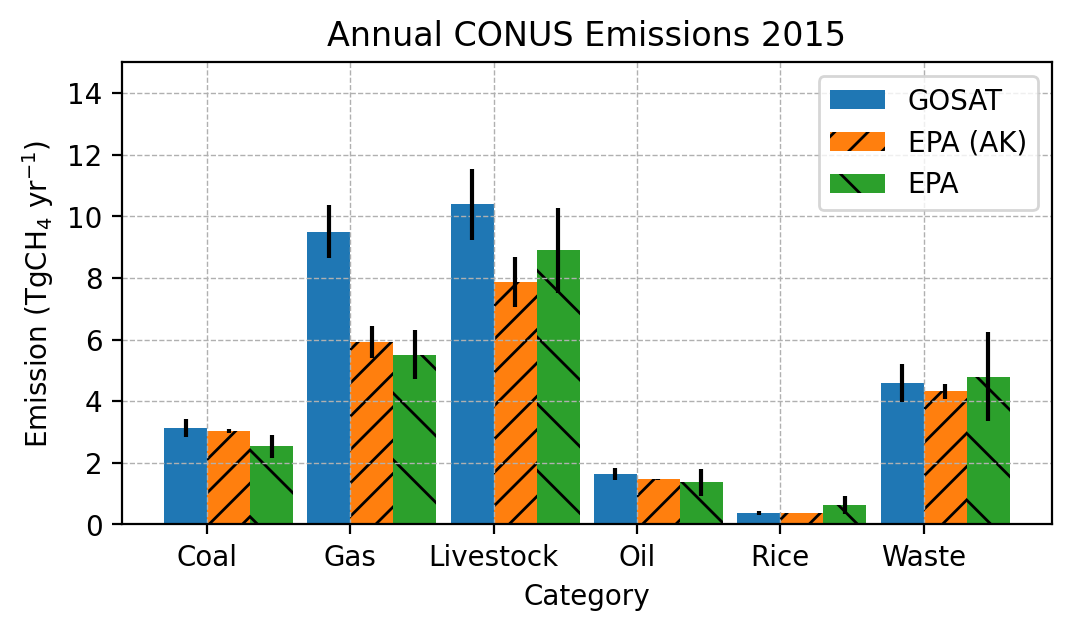

In [7]:
# Make a bar plot to compare the EPA inventory data with the GOSAT inversion data
makeBarPlot(ana_dict, epa_error_params, inventory="epa", analysis_year=analysis_year)

In the bar plot, the difference between the orange and green bars is due to the averaging kernel of the GOSAT flux inversion. The orange bar should be compared with the GOSAT estimates (blue bars).

Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.
****The output is a scrollable list of maps.***
Generating maps for category: livestock


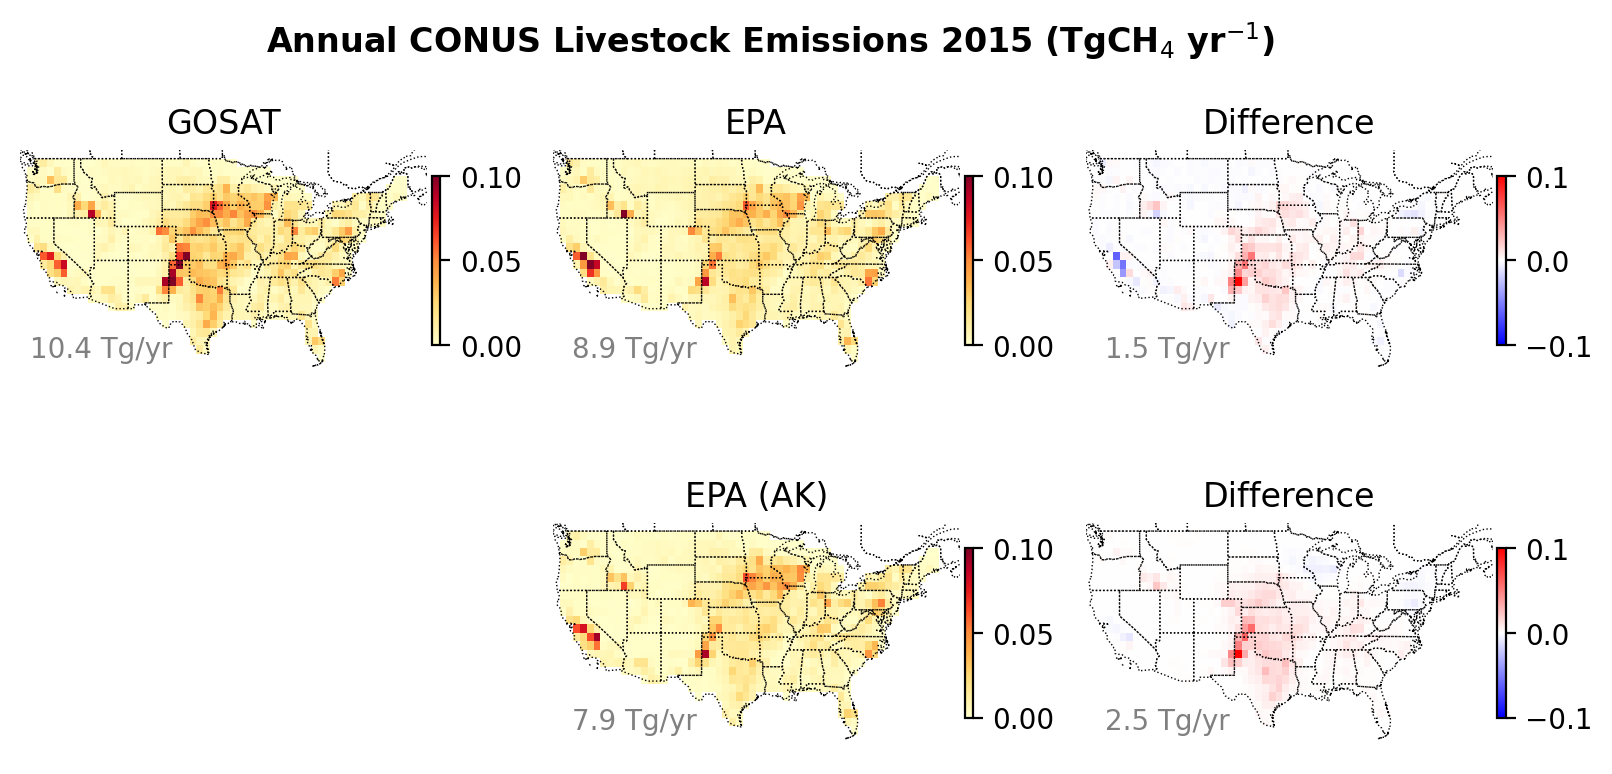

Generating maps for category: waste


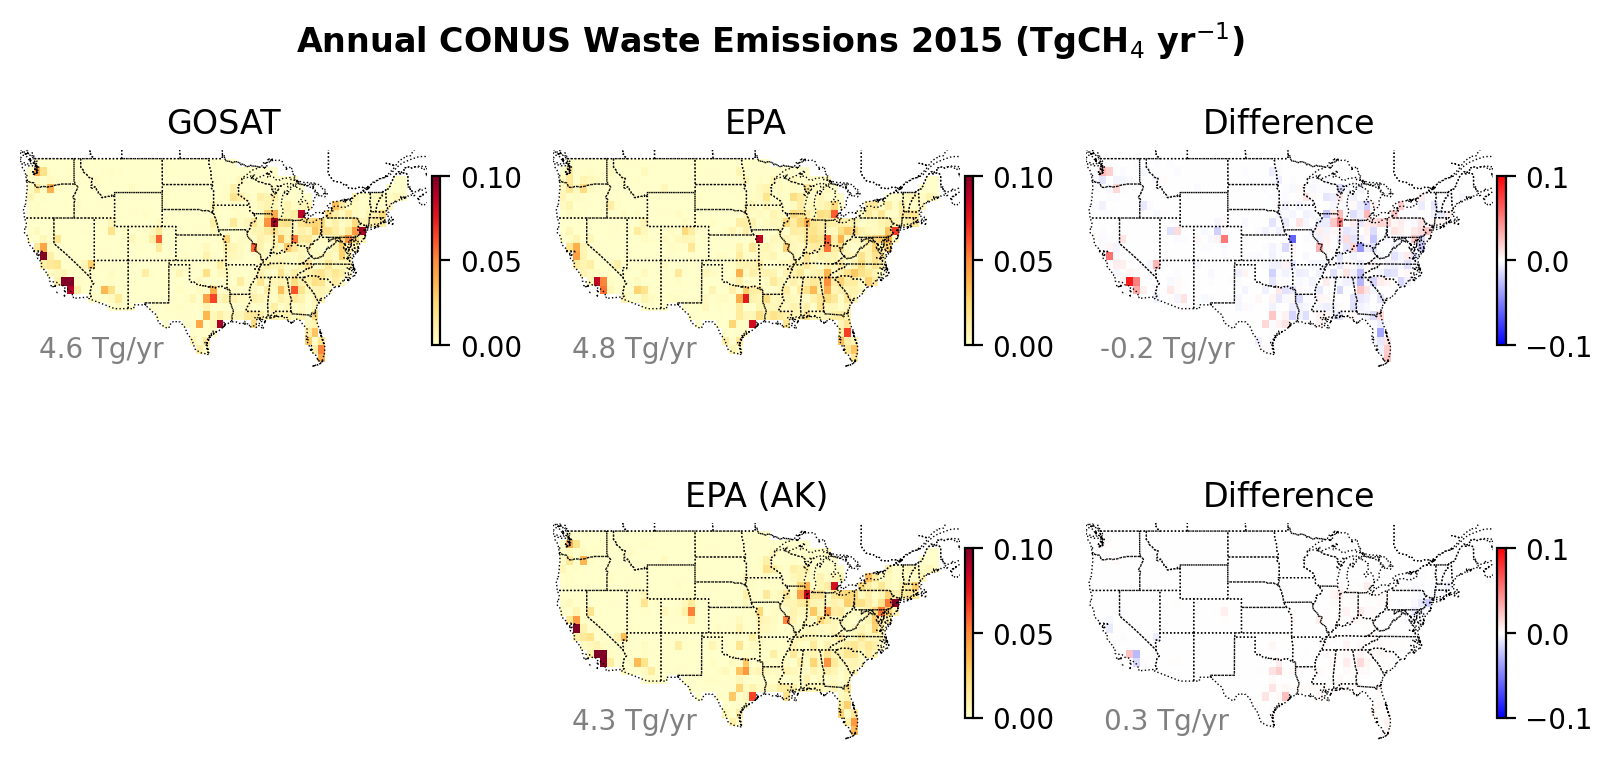

Generating maps for category: rice


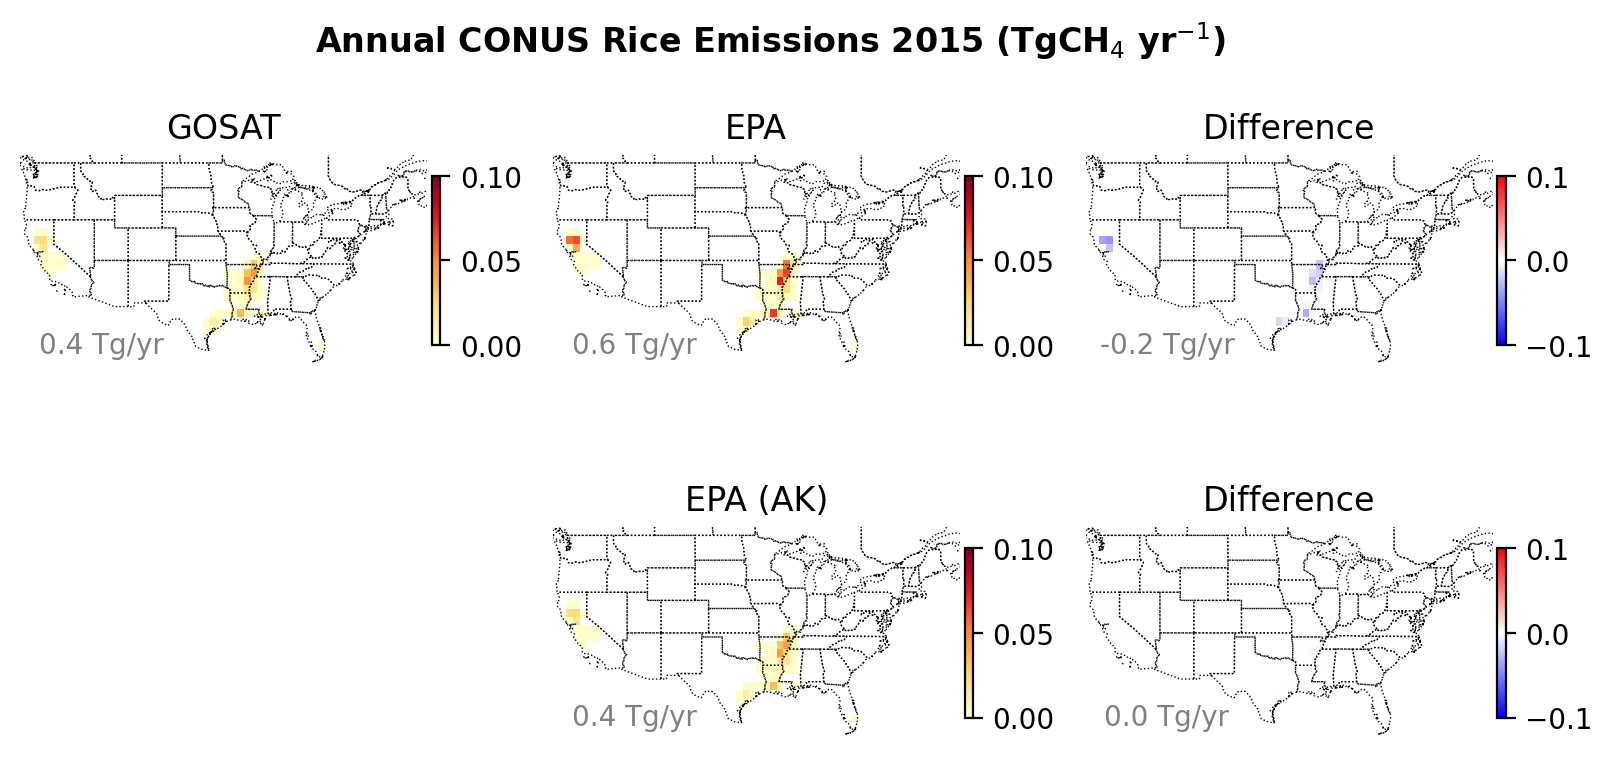

Generating maps for category: coal


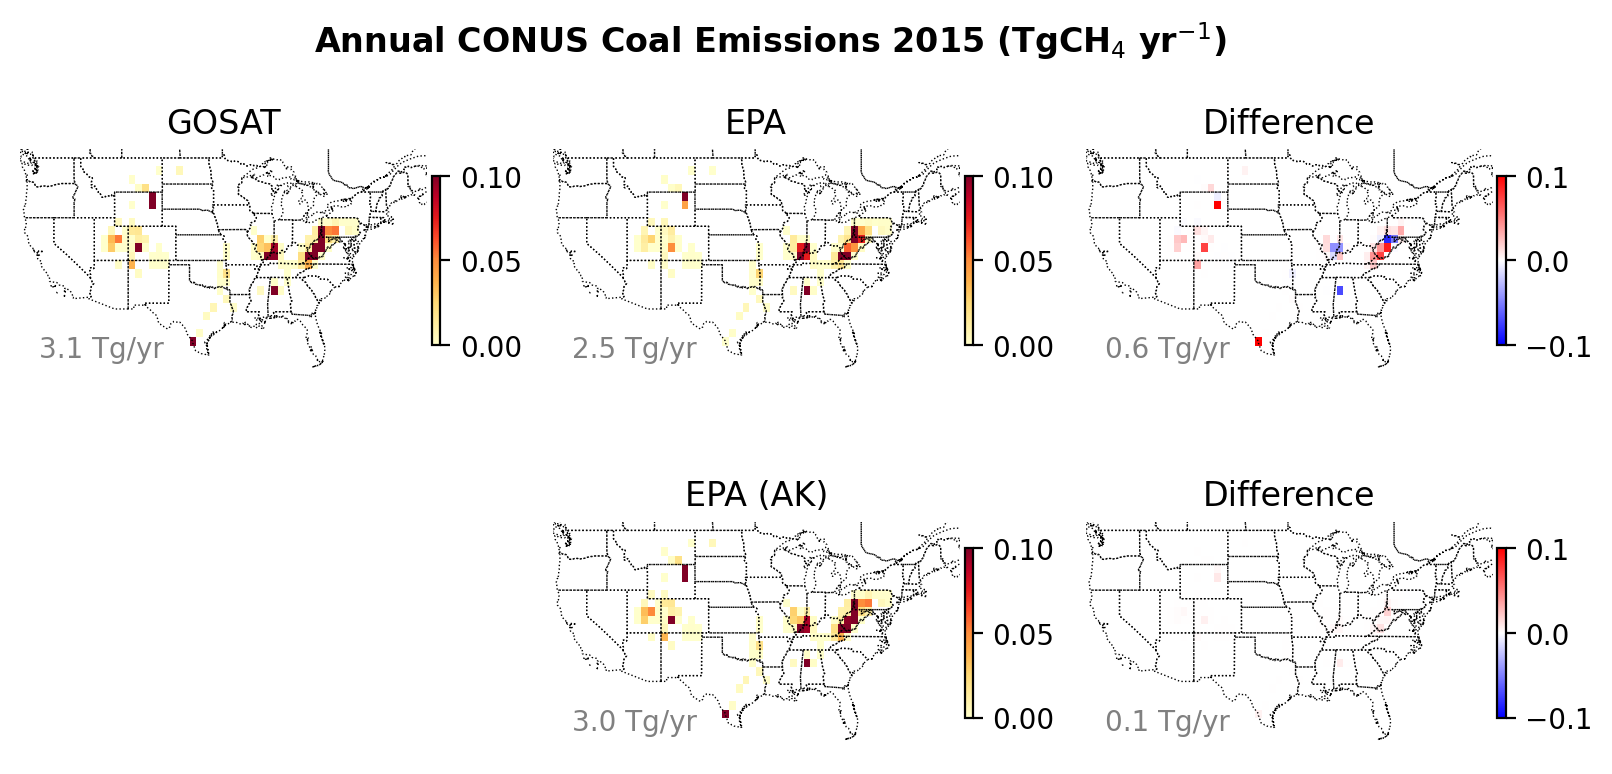

Generating maps for category: oil


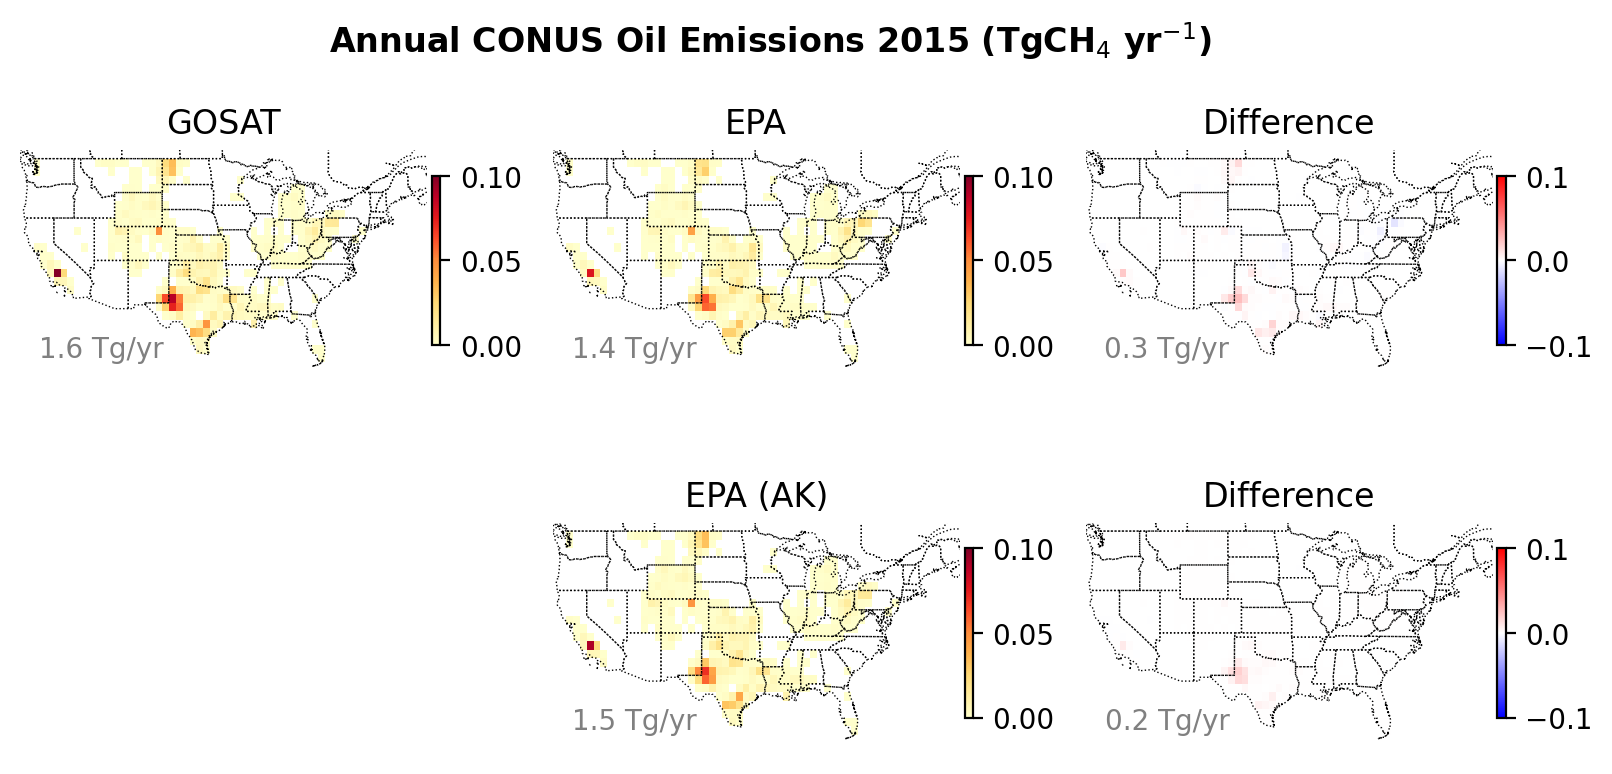

Generating maps for category: gas


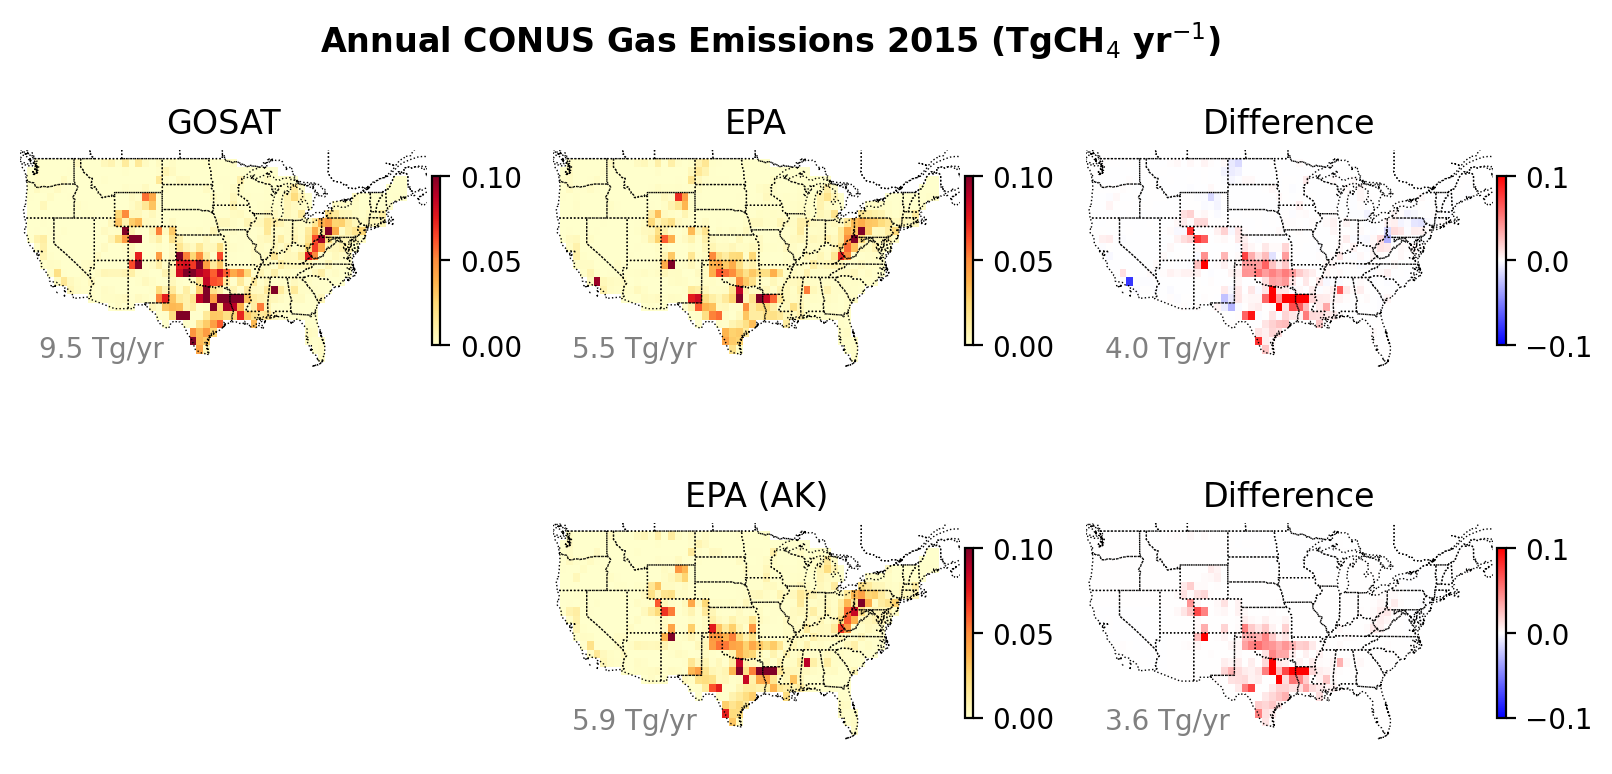

Output(layout=Layout(height='500px'))

In [8]:
# Create a GeoPandas DataFrame from the analysis dictionary for the "epa" inventory
gdf_epa = makeGeoPandasDataFrame(ana_dict, inventory="epa")

print ("****The output is a scrollable list of maps.***")
from ipywidgets import Output

# Iterate over each unique category in the 'cat' column of the GeoPandas DataFrame
out = Output(layout={'overflow_y': 'scroll', 'height': '500px'}) 
cats= list(gdf_epa['cat'].unique())
for cat in cats:
        print(f"Generating maps for category: {cat}")
    # For each category, generate map plots using the MakeMaps function
        MakeMaps(gdf_epa, cat, inventory="epa", analysis_year=analysis_year)
display(out)

The difference between the two middle panels of each sector plot is due to the averaging kernel of the GOSAT flux inversion.

# EDGAR inventory
Emissions Database for Global Atmospheric Research (EDGAR) Version 6 


Monforti Ferrario, Fabio; Crippa, Monica; Guizzardi, Diego; Muntean, Marilena; Schaaf, Edwin; Lo Vullo, Eleonora; Solazzo, Efisio; Olivier, Jos; Vignati, Elisabetta (2021): EDGAR v6.0 Greenhouse Gas Emissions. European Commission, Joint Research Centre (JRC) [Dataset]. 




In [9]:
# Read and process EDGAR inventory data for the specified analysis year
edgar_data_folder = data_folder_path + "/EDGAR_v6_2015_only/"
edgar_dat = readEdgarData(edgar_data_folder, analysis_year=analysis_year)

# Integrate EDGAR inventory data into the analysis dictionary (ana_dict) for the year 2015
ana_dict = addEdgar2AnaDict(ana_dict, edgar_dat, analysis_year=2015)
# ana_dict = FilterforCONUS(ana_dict)

Reading Edgar emission inventory Data for 2015
Adding Edgar data to ana_dict


Note: We assume that EDGAR has the same sector-wise uncertainity as EPA. 

In [10]:
# Perform AK correction on the analysis dictionary focusing on EDGAR data variables ("x_edgar" and "S_edgar")
ana_dict_edgar = performAKcorrection(ana_dict, x_var="x_edgar", S_var="S_edgar")

Performing GOSAT flux inversions AK Correction


Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.


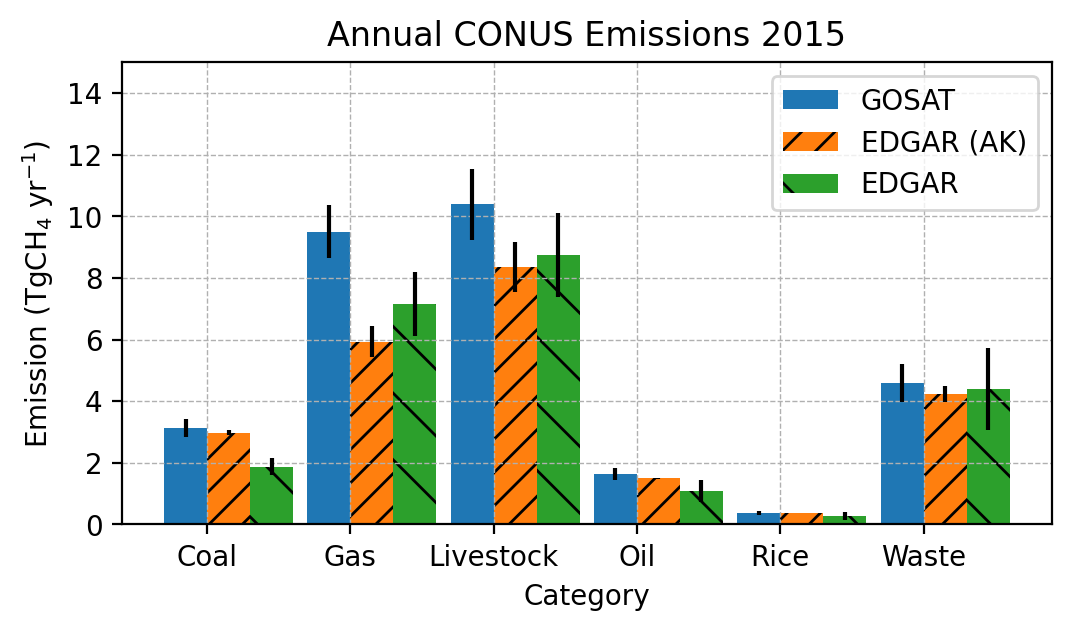

In [11]:
# Plot comparison of EDGAR and GOSAT total emissions for each sector. 
makeBarPlot(ana_dict_edgar, epa_error_params, inventory="edgar", analysis_year=analysis_year)

In [12]:
# Create a GeoPandas DataFrame from the analysis dictionary for the "edgar" inventory
gdf = makeGeoPandasDataFrame(ana_dict, inventory="edgar")
print ("***The output is a scrollable list of maps.***")
out = Output(layout={'overflow_y': 'scroll', 'height': '500px'})


# Iterate over each unique category in the 'cat' column of the GeoPandas DataFrame
with out:
    for cat in gdf['cat'].unique():
        # For each category, generate map plots using the MakeMaps function
        MakeMaps(gdf, cat, inventory="edgar", analysis_year= analysis_year)
display(out)


Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.
***The output is a scrollable list of maps.***


Output(layout=Layout(height='500px'))

# FOG Oil/Gas Fuel Inventory 
Francoeur, C. B., McDonald, B. C., Gilman, J. B., Zarzana, K. J., Dix, B., Brown, S. S., de Gouw, J. A., Frost, G. J., Li, M., McKeen, S. A., Peischl, J., Pollack, I. B., Ryerson, T. B., Thompson, C., Warneke, C., and Trainer, M.: Quantifying Methane and Ozone Precursor Emissions from Oil and Gas Production Regions across the Contiguous US, Environ. Sci. Technol., 55, 9129–9139, https://doi.org/10.1021/acs.est.0c07352, 2021.

Note: We assume that FOG emissions have the same uncertainty as EPA oil/gas emissions.
The FOG inventory for the year 2015 is available at: https://csl.noaa.gov/groups/csl7/measurements/2015songnex/emissions/ (last accessed: 2025-04-10).

In [13]:
# Create a oil/Gas fuel category within the GOSAT data dictionary to accommodate FOG emissions data
ana_dict_fog = createFossilCategory(ana_dict)

# Adjust the resolution of the FOG data to match the GOSAT data dictionary's resolution
# This involves clustering or aggregating the FOG data, which has a native resolution of 4x4 km^2
fog_data_path = data_folder_path
ana_dict_fog = clusterFOG2GOSAT(fog_data_path, ana_dict_fog, analysis_year)

Creating Oil/Gas(= oil + gas) production Category
Clustering FOG data to GOSAT Grid Resolution


In [14]:
# Perform AK correction for the oil/gas category using EPA data
print("EPA fossil:", end=" ")
ana_dict_fog = performAKcorrection(ana_dict_fog, x_var="x_epa", S_var="S_epa")


# Perform AK correction for the oil/gas category using FOG data
print("FOG fossil:", end=" ")
ana_dict_fog = performAKcorrection(ana_dict_fog, x_var="x_fog", S_var="S_fog")

# Perform AK correction for the oil/gas category using EDGAR data
print("EDGAR fossil:", end=" ")
ana_dict_fog = performAKcorrection(ana_dict_fog, x_var="x_edgar", S_var="S_edgar")

# Modify the error parameters for the oil/gas category to include contributions from gas and oil.
# This step assumes that the "gas" key in the `epa_error_params` dictionary is a placeholder and needs to be updated.
epa_error_params["fossil"] = epa_error_params["gas"]  # This line needs modification to accurately represent fossil sources.

EPA fossil: Performing GOSAT flux inversions AK Correction
FOG fossil: Performing GOSAT flux inversions AK Correction
EDGAR fossil: Performing GOSAT flux inversions AK Correction


Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.


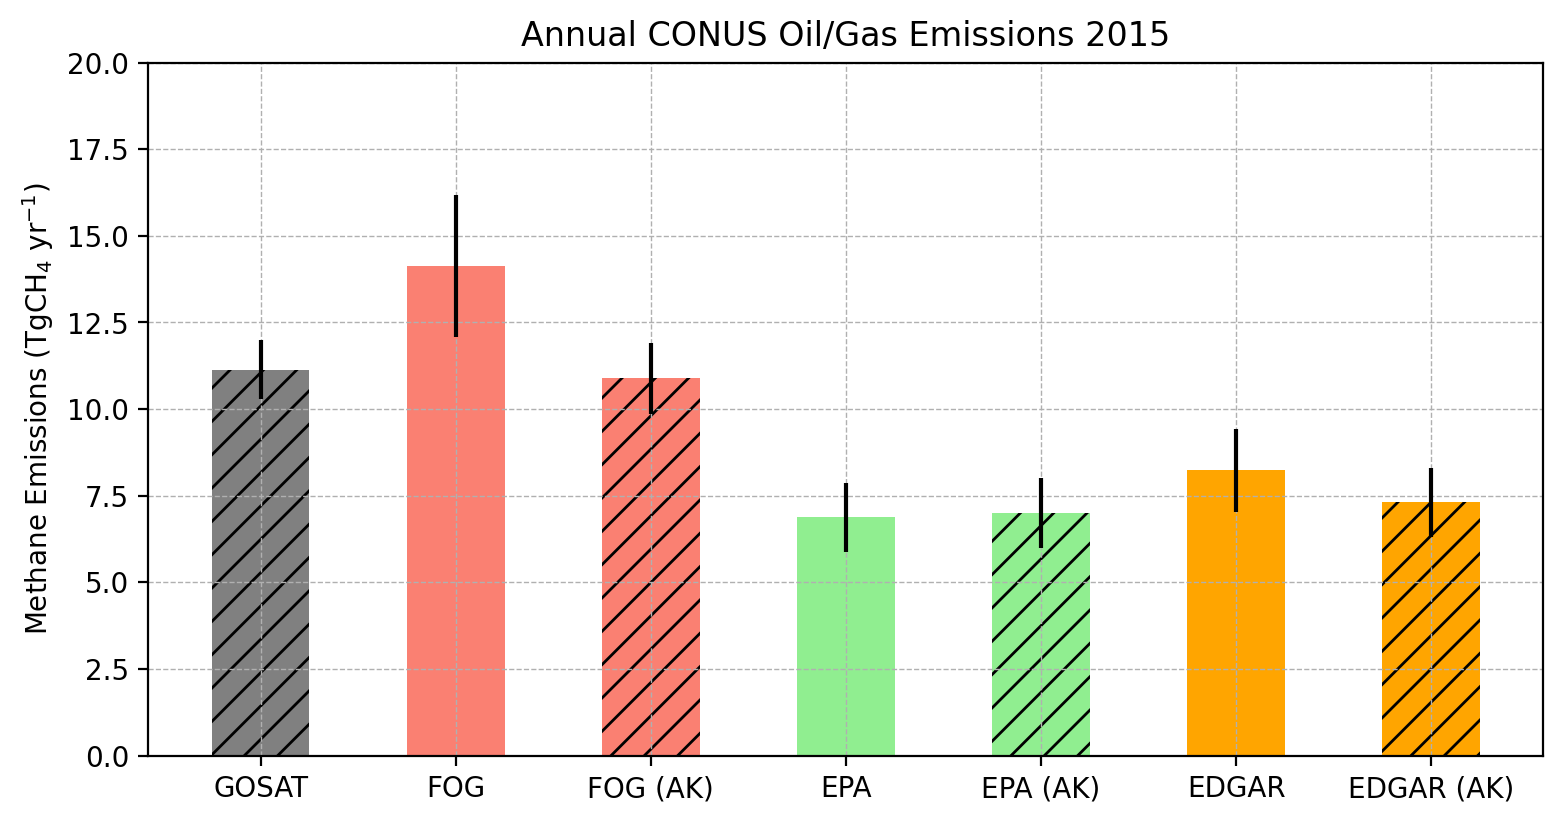

In [15]:
# Bar plot of oil/gas emissions from the three inventories and GOSAT flux inversion
makeBarPlotFossil(ana_dict_fog, epa_error_params, inventory="epa", analysis_year=analysis_year)

The FOG estimates are in good agreement with GOSAT inversion estimates after applying the GOSAT averaging kernel. EPA and EDGAR estimates agree with each other (after applying GOSAT averaging kernel) but underestimate the GOSAT inversion and FOG estimates.



Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.
Country 'United States' not found in the shapefile.


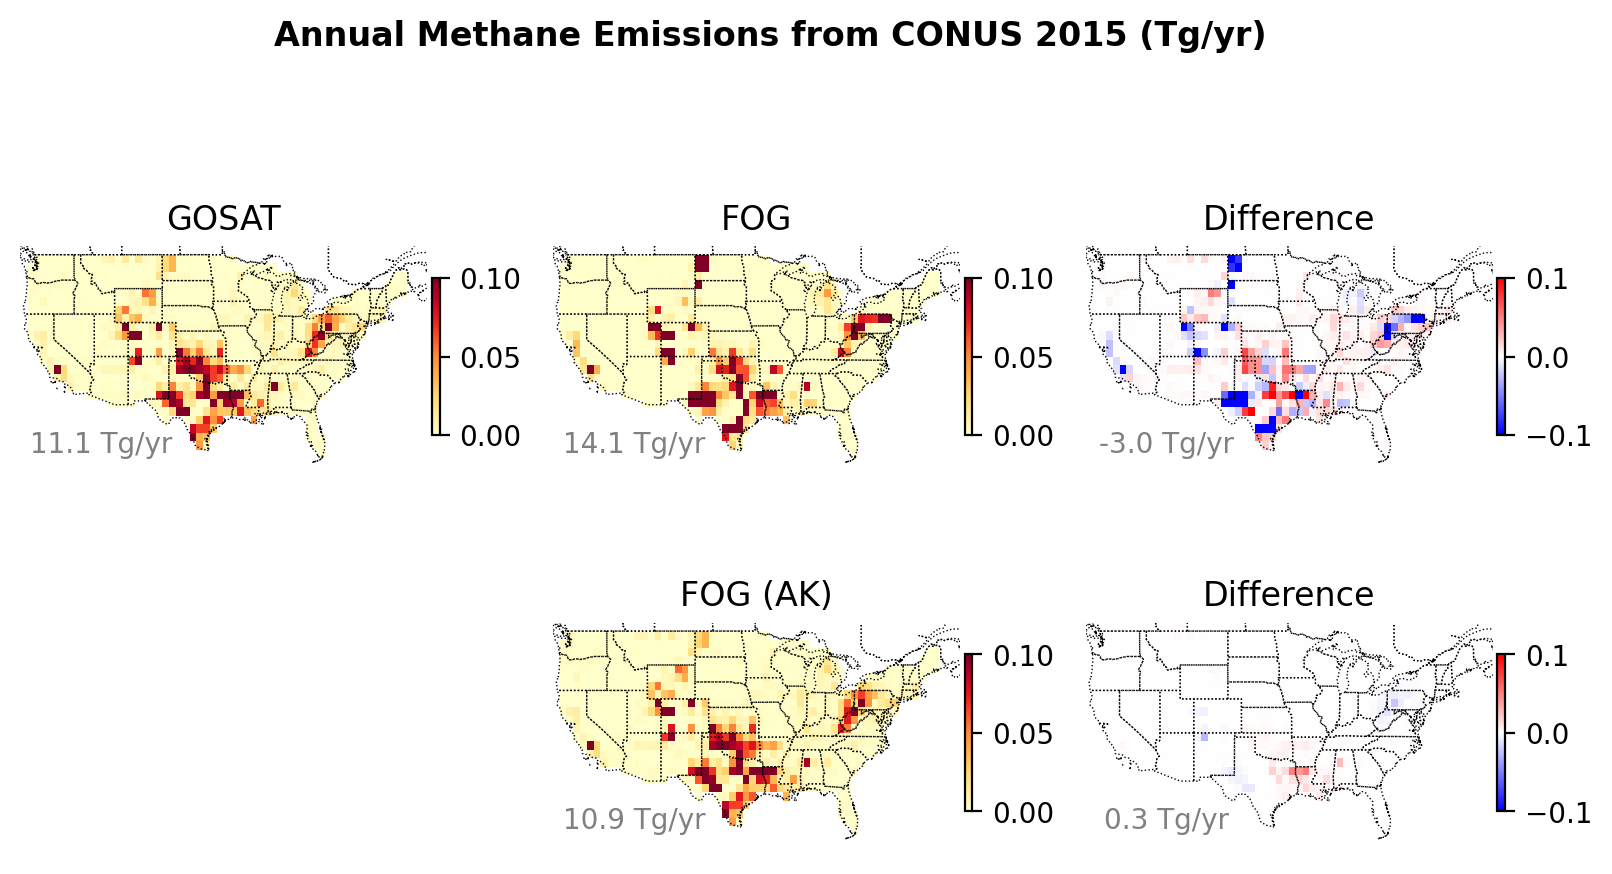

In [16]:
# Create map plots for fossil fuel emissions

# First, convert the analysis data into a GeoPandas DataFrame suitable for mapping
gdf_fog = makeGeoPandasDataFrameFOG(ana_dict_fog)

# Then, use the GeoPandas DataFrame to create maps of fossil fuel emissions for the specified analysis year
MakeFossilMaps(gdf_fog, analysis_year)

## Conclusion

1. **Importance of Averaging Kernels:**
   Accounting for truth sensitivity through the averaging kernel of flux inversions is essential for accurately evaluating methane emission inventories. This ensures that comparisons between bottom-up inventories and top-down satellite estimates are valid and reliable.

2. **Inventory Performance:**
   The Fossil Oil and Gas (FOG) estimates closely align with GOSAT flux inversion results after applying the averaging kernel. In contrast, the EPA and EDGAR inventories, while consistent with each other after correction, tend to underestimate methane emissions compared to satellite-derived estimates.

3. **Implications and Future Directions:**
   The underestimation by EPA and EDGAR suggests a need to enhance their methodologies by incorporating satellite-based data and refining emission factors.

---

This analysis highlights the necessity of integrating satellite-based flux inversions with traditional emission inventories to achieve a more accurate and comprehensive understanding of methane emissions. Addressing the identified discrepancies will improve emission assessments and inform better policy and mitigation efforts.